In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 

In [2]:
# Load Dataset
df = pd.read_csv("ipl.csv")  
print("Dataset Preview:")
print(df.head())

runs = df["Top_Scorer_Runs"]
wickets = df["Top_Bowler_Wickets"]

print("\n------ NUMPY CALCULATIONS ------")

print("Mean Runs:", np.mean(runs))
print("Median Runs:", np.median(runs))
print("Mode Runs:", stats.mode(runs, keepdims=True).mode[0])

print("Mean Wickets:", np.mean(wickets))
print("Median Wickets:", np.median(wickets))
print("Mode Wickets:", stats.mode(wickets, keepdims=True).mode[0])

# Correlation between runs and wickets
print("\nCorrelation (Runs vs Wickets):", np.corrcoef(runs, wickets)[0,1])

Dataset Preview:
   MatchID  Season Team1 Team2 Winner Player_of_Match  Runs_Scored  Wickets  \
0        1    2022    MI   CSK     MI    Rohit Sharma           88        0   
1        2    2022   RCB   KKR    RCB  Faf du Plessis           72        0   
2        3    2022    GT    RR     GT    Shubman Gill           96        0   
3        4    2022   SRH    DC     DC    Rishabh Pant           62        0   
4        5    2022  PBKS   LSG    LSG        KL Rahul           84        0   

       Top_Scorer  Top_Scorer_Runs      Top_Bowler  Top_Bowler_Wickets  \
0    Rohit Sharma               88  Jasprit Bumrah                   3   
1  Faf du Plessis               72   Harshal Patel                   4   
2    Shubman Gill               96     Rashid Khan                   3   
3    Rishabh Pant               62   Kuldeep Yadav                   4   
4        KL Rahul               84      Avesh Khan                   3   

  Toss_Winner Toss_Decision  
0         CSK           Bat  
1  

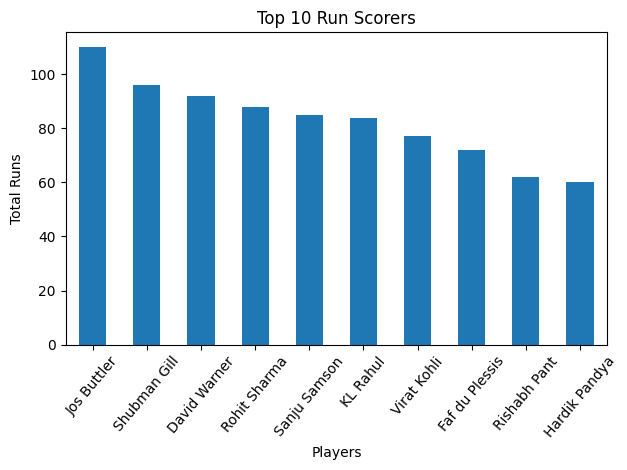

In [8]:
# 1. Top Run Scorers


top_runs = df.groupby("Top_Scorer")["Top_Scorer_Runs"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_runs.plot(kind='bar')
plt.title("Top 10 Run Scorers")
plt.xlabel("Players")
plt.ylabel("Total Runs")
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()



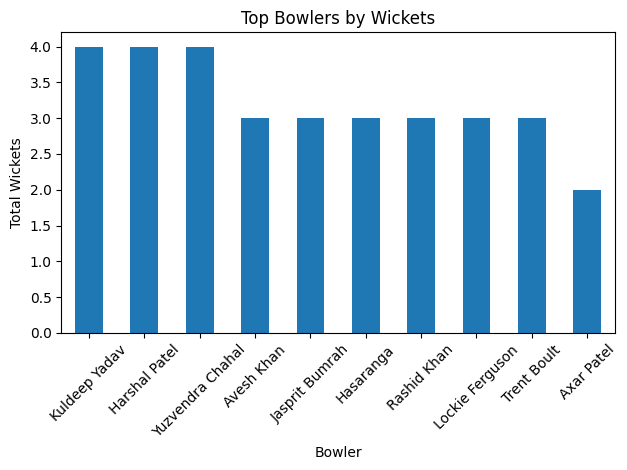

In [4]:
# 2. Top Bowlers by Wickets

top_wickets = df.groupby("Top_Bowler")["Top_Bowler_Wickets"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_wickets.plot(kind='bar')
plt.title("Top Bowlers by Wickets")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


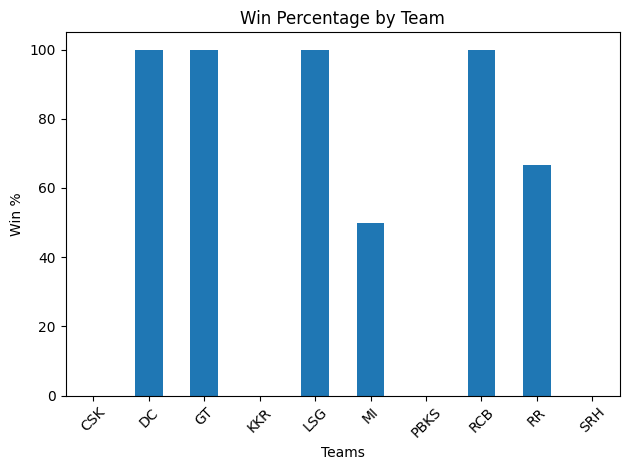

In [5]:
# 3. Win Percentage of Teams

matches_played = pd.concat([df["Team1"], df["Team2"]]).value_counts()
wins = df["Winner"].value_counts()
win_percentage = (wins / matches_played * 100).fillna(0)

plt.figure()
win_percentage.plot(kind='bar')
plt.title("Win Percentage by Team")
plt.xlabel("Teams")
plt.ylabel("Win %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

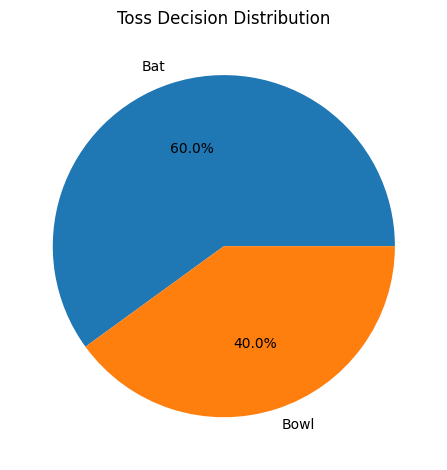

In [6]:
# 4. Toss Decision vs Match Result

toss_decision = df["Toss_Decision"].value_counts()

plt.figure()
toss_decision.plot(kind='pie', autopct="%1.1f%%")
plt.title("Toss Decision Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

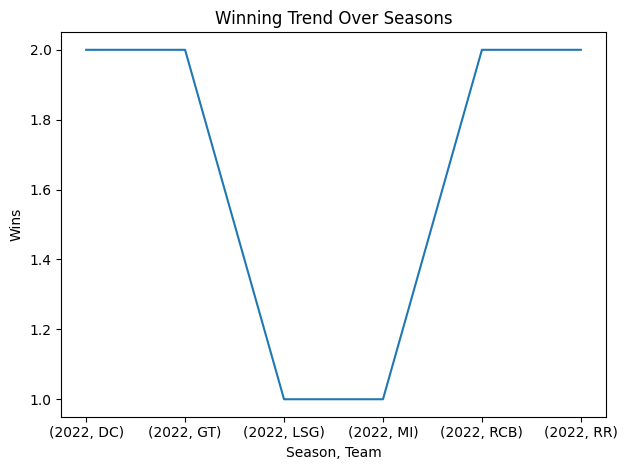

In [7]:
# 5. Winning Trend Over Seasons

season_trend = df.groupby(["Season", "Winner"]).size()

plt.figure()
season_trend.plot()
plt.title("Winning Trend Over Seasons")
plt.xlabel("Season, Team")
plt.ylabel("Wins")
plt.tight_layout()
plt.show()